<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario1_exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harish M K  - 24BAD031
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
RMSE: 2.0009674348275257
MAE: 1.5392221279540728
      movieId                           title                 genres
659       858           Godfather, T

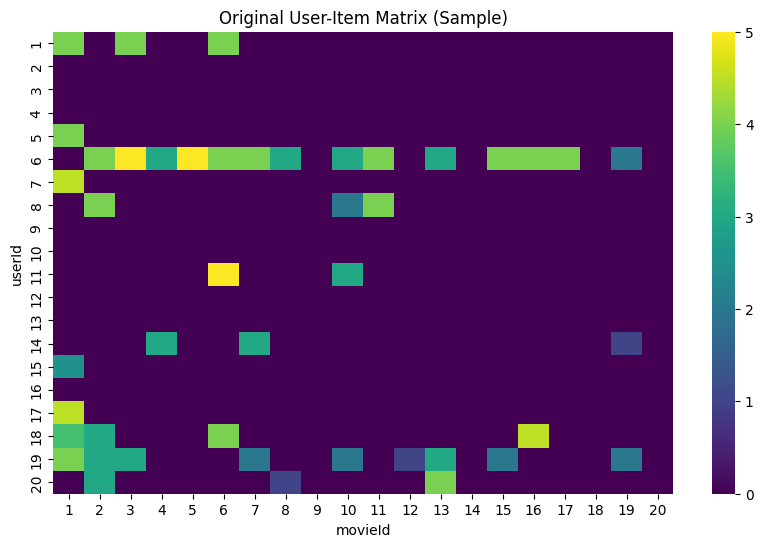

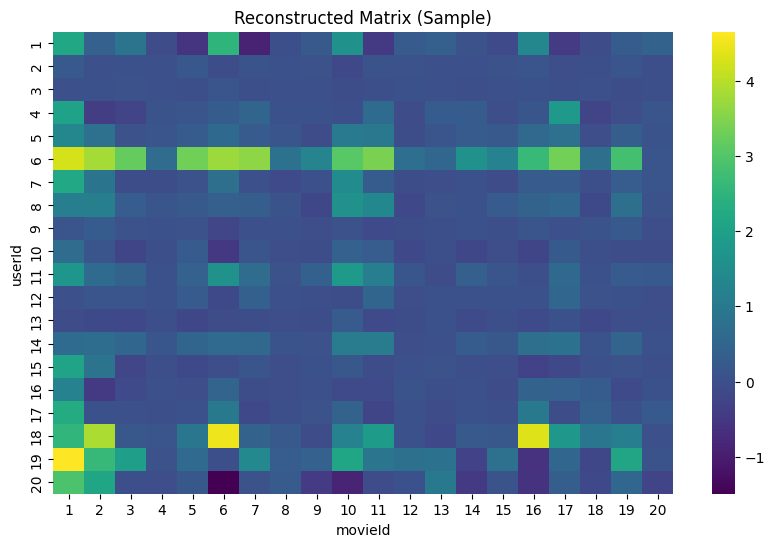

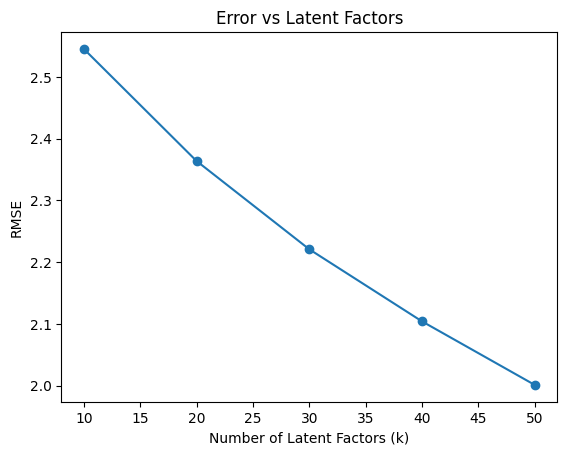

In [4]:
print("Harish M K  - 24BAD031")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print(ratings.head())
print(movies.head())

df = pd.merge(ratings, movies, on='movieId')

user_item_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')

user_item_matrix_filled = user_item_matrix.fillna(0)

R = user_item_matrix_filled.values

user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

k = 50

U, sigma, Vt = svds(R_demeaned, k=k)

sigma = np.diag(sigma)

R_pred = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

pred_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

def get_pred_rating(user, movie):
    return pred_df.loc[user, movie]

y_true = []
y_pred = []

for row in test_data.itertuples():
    try:
        pred = pred_df.loc[row.userId, row.movieId]
        y_true.append(row.rating)
        y_pred.append(pred)
    except:
        continue

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

def recommend_movies(user_id, num_recommendations=10):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = user_row.drop(already_rated)
    top_movies = recommendations.sort_values(ascending=False).head(num_recommendations)

    return movies[movies['movieId'].isin(top_movies.index)]

print(recommend_movies(user_id=1, num_recommendations=5))

plt.figure(figsize=(10, 6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap='viridis')
plt.title("Original User-Item Matrix (Sample)")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pred_df.iloc[:20, :20], cmap='viridis')
plt.title("Reconstructed Matrix (Sample)")
plt.show()

k_values = [10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(R_demeaned, k=k)
    sigma = np.diag(sigma)
    R_pred = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

    pred_df_temp = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

    y_pred_temp = []
    y_true_temp = []

    for row in test_data.itertuples():
        try:
            pred = pred_df_temp.loc[row.userId, row.movieId]
            y_true_temp.append(row.rating)
            y_pred_temp.append(pred)
        except:
            continue

    rmse_temp = np.sqrt(mean_squared_error(y_true_temp, y_pred_temp))
    rmse_list.append(rmse_temp)

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()